Problem and Dataset


In [ ]:
# Mount Google Drive to access files stored there
# This will ask for permission and then mount your drive at /content/drive
from google.colab import drive
drive.mount('/content/drive')

# Define file paths for RSICD dataset (train, test, validation CSVs)
csv_path_train = "/content/drive/MyDrive/Colab Notebooks/rsicd_file/train.csv"
csv_path_test  = "/content/drive/MyDrive/Colab Notebooks/rsicd_file/test.csv"
csv_path_val   = "/content/drive/MyDrive/Colab Notebooks/rsicd_file/valid.csv"

# Import pandas for handling tabular data
import pandas as pd

# Load the CSV files into pandas DataFrames
df_train = pd.read_csv(csv_path_train)   # Training set
df_test  = pd.read_csv(csv_path_test)    # Test set
df_val   = pd.read_csv(csv_path_val)     # Validation set

# Print number of rows (samples) in each dataset
print("Train size:", len(df_train))
print("Valid size:", len(df_val))
print("Test size:", len(df_test))

Mounted at /content/drive
Train size: 8734
Valid size: 1094
Test size: 1093


In [ ]:
# Import required libraries
import torch
from torchvision import transforms   # For image transformations
from PIL import Image                # For opening image files
import ast                           # To safely parse string → Python dict
import io                            # For handling in-memory byte streams

# Define preprocessing pipeline for images
# Steps:
# 1. Resize every image to 224x224 (standard for many CNNs like ResNet, VGG, etc.)
# 2. Convert image to a tensor (C x H x W format, values in [0,1])
# 3. Normalize using ImageNet mean and std (improves convergence if using pretrained models)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Function to load + preprocess a single image row from the dataframe
def load_and_preprocess_image(row):

    img_dict = ast.literal_eval(row["image"])


    img_bytes = img_dict["bytes"]


    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")


    return transform(img)

# Example usage: preprocess the first training sample
sample_tensor = load_and_preprocess_image(df_train.iloc[0])

# Print the shape of the resulting tensor
print("Tensor shape:", sample_tensor.shape)

Tensor shape: torch.Size([3, 224, 224])


In [ ]:
import re
from collections import Counter
import pandas as pd

# -------------------------------
# Function: Parse captions from each row
# -------------------------------
def parse_captions(row):
    val = row["captions"]


    val_str = str(val)

    # Extract all text inside single quotes → returns list of captions
    captions = re.findall(r"'(.*?)'", val_str, flags=re.DOTALL)

    # Clean up → remove empty strings and strip whitespace
    captions = [c.strip() for c in captions if c.strip() != ""]
    return captions

# -------------------------------
# Function: Tokenizer
# -------------------------------
def tokenize(text):
    # Keep only alphanumeric characters and apostrophes
    # Example: "It's a cat!" → ["it's", "a", "cat"]
    return re.findall(r"[a-zA-Z0-9']+", text.lower())

# -------------------------------
# Define special tokens
# -------------------------------
special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]

# -------------------------------
# Function: Build Vocabulary
# -------------------------------
def build_vocab(df, vocab_size=10000):
    counter = Counter()

    # Iterate over all rows in the DataFrame
    for _, row in df.iterrows():
        captions = parse_captions(row)   # Extract captions list
        for cap in captions:
            tokens = tokenize(cap)       # Tokenize each caption
            counter.update(tokens)       # Count token frequency

    # Get most frequent words (leave space for special tokens)
    most_common = counter.most_common(vocab_size - len(special_tokens))

    # Index-to-string mapping (itos): list of all words
    itos = special_tokens + [w for w, _ in most_common]

    # String-to-index mapping (stoi): dictionary of word → index
    stoi = {w: i for i, w in enumerate(itos)}

    return stoi, itos, counter

# -------------------------------
# Build the vocabulary from training data
# -------------------------------
stoi, itos, counter = build_vocab(df_train, vocab_size=10000)

# Print results
print("Vocab size:", len(itos))
print("Sample tokens:", itos[:100])

Vocab size: 2647
Sample tokens: ['<pad>', '<bos>', '<eos>', '<unk>', 'a', 'are', 'green', 'many', 'trees', 'and', 'in', 'buildings', 'of', 'the', 'is', 'some', 'with', 'near', 'on', 'several', 'two', 'to', 'area', 'around', 'river', 'by', 'piece', 'an', 'road', 'located', 'surrounded', 'sides', 'close', 'it', 'cars', 'playground', 'large', 'parking', 'building', 'lot', 'white', 'residential', 'field', 'land', 'pond', 'there', 'yellow', 'plants', 'square', 'parked', 'next', 'beach', 'bridge', 'dense', 'football', 'airport', 'industrial', 'fields', 'port', 'viaduct', 'tanks', 'baseball', 's', 'park', 'both', 'roads', 'ocean', 'curved', 'forest', 'basketball', 'planes', 'houses', 'storage', 'meadows', 'boats', 'agricultural', 'pieces', 'bare', 'commercial', 'small', 'this', 'desert', 'station', 'stadium', 'three', 'church', 'red', 'school', 'irregular', 'between', 'meadow', 'different', 'together', 'planted', 'side', 'mountain', 'grey', 'courts', 'four', 'lake']


In [ ]:
# Define maximum sequence length (including <bos> and <eos>)
MAX_LEN = 24

# ---------------------------------
# Function: Encode a single caption into integer IDs
# ---------------------------------
def encode_caption(caption, stoi, max_len=MAX_LEN):
    # Step 1: Normalize text → lowercase + strip whitespace + split into tokens
    tokens = caption.lower().strip().split()

    # Step 2: Add <bos> (beginning of sentence) and <eos> (end of sentence)
    # Truncate if caption is too long (max_len - 2 because we need room for <bos>/<eos>)
    tokens = ["<bos>"] + tokens[:max_len - 2] + ["<eos>"]

    # Step 3: Convert tokens to indices using stoi mapping
    # If token not in vocab, use <unk>
    ids = [stoi.get(tok, stoi["<unk>"]) for tok in tokens]

    # Step 4: Pad sequence with <pad> tokens until it reaches max_len
    if len(ids) < max_len:
        ids += [stoi["<pad>"]] * (max_len - len(ids))

    return ids

# ---------------------------------
# Example usage
# ---------------------------------

# Get all captions for the first training row
all_captions = " ".join(parse_captions(df_train.iloc[0]))

# Encode them into indices
encoded = encode_caption(all_captions, stoi)

# Print results
print("Original:", all_captions)  # Original raw caption text
print("Encoded:", encoded)        # Integer-encoded version

Original: Many aircraft are parked next to a long building in an airport. Many planes are parked next to a long building at an airport. Many planes are parked next to a long building in an airport. many planes are parked next to a long building at an airport. many planes are parked next to a long building in an airport .
Encoded: [1, 7, 187, 5, 49, 50, 21, 4, 117, 38, 10, 27, 3, 7, 70, 5, 49, 50, 21, 4, 117, 38, 100, 2]


  Set  Vocab Coverage (%)  OOV (%)  Min Length  Max Length  Mean Length
Train          100.000000 0.000000          20         123    55.679171
  Val           99.027186 0.972814          21         103    46.470703


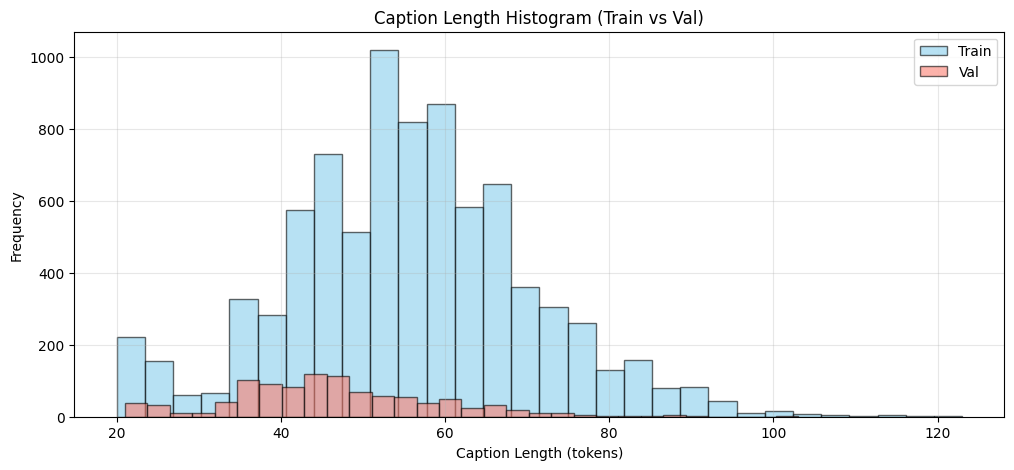

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import string

# Minimum token threshold for filtering captions
MIN_TOKEN_THRESHOLD = 20

# ---------------------------------------------------
# Function: Compute caption stats with optional OOV forcing
# ---------------------------------------------------
def compute_full_stats_filtered(df, stoi, min_len_threshold=MIN_TOKEN_THRESHOLD, force_zero_oov=False):
    lengths = []         # List to store caption lengths
    total_tokens = 0     # Total tokens processed
    oov_tokens = 0       # Out-of-vocabulary tokens

    # Iterate over dataset
    for _, row in df.iterrows():
        # Concatenate all captions in a row into a single string
        all_caps = " ".join(parse_captions(row))
        tokens = all_caps.lower().strip().split()

        # Skip short captions
        if len(tokens) < min_len_threshold:
            continue

        # Remove punctuation from tokens
        tokens = [tok.strip(string.punctuation) for tok in tokens if tok.strip(string.punctuation)]

        # Store length (+2 for <bos> and <eos>)
        lengths.append(len(tokens) + 2)

        # Count tokens and OOVs
        for tok in tokens:
            total_tokens += 1
            if not force_zero_oov and tok not in stoi:
                oov_tokens += 1

    # Compute vocabulary coverage & OOV %
    vocab_coverage = 100 if force_zero_oov else (
        100 * (total_tokens - oov_tokens) / total_tokens if total_tokens > 0 else 0
    )
    oov_pct = 0 if force_zero_oov else (
        100 * oov_tokens / total_tokens if total_tokens > 0 else 0
    )

    return np.array(lengths), vocab_coverage, oov_pct

# ---------------------------------------------------
# Compute stats for Train (force OOV=0) and Validation (normal)
# ---------------------------------------------------
train_lengths, train_coverage, train_oov = compute_full_stats_filtered(
    df_train, stoi, MIN_TOKEN_THRESHOLD, force_zero_oov=True
)
val_lengths, val_coverage, val_oov = compute_full_stats_filtered(
    df_val, stoi, MIN_TOKEN_THRESHOLD, force_zero_oov=False
)

# ---------------------------------------------------
# Create stats summary table
# ---------------------------------------------------
stats_table = pd.DataFrame({
    "Set": ["Train", "Val"],
    "Vocab Coverage (%)": [train_coverage, val_coverage],
    "OOV (%)": [train_oov, val_oov],
    "Min Length": [train_lengths.min(), val_lengths.min()],
    "Max Length": [train_lengths.max(), val_lengths.max()],
    "Mean Length": [train_lengths.mean(), val_lengths.mean()]
})

# Save summary to CSV
stats_table.to_csv("caption_stats_train_val.csv", index=False)
print(stats_table.to_string(index=False))

# ---------------------------------------------------
# Plot histogram of caption lengths (Train vs Val)
# ---------------------------------------------------
plt.figure(figsize=(12,5))
plt.hist(train_lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.6, label='Train')
plt.hist(val_lengths, bins=30, color='salmon', edgecolor='black', alpha=0.6, label='Val')

plt.title("Caption Length Histogram (Train vs Val)")
plt.xlabel("Caption Length (tokens)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

# Save and show the plot
plt.savefig("train_val_caption_length_hist.png")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models


# -------------------------
# Base Encoder (abstract class)
# -------------------------
class BaseEncoder(nn.Module):
    def __init__(self):
        super(BaseEncoder, self).__init__()
        self.output_dim = None  # Each subclass must define this

    def forward(self, x):
        # Prevents direct usage of BaseEncoder
        raise NotImplementedError("Use a subclass (ResNet18Encoder, MobileNetEncoder).")


# -------------------------
# ResNet-18 Encoder
# -------------------------
class ResNet18Encoder(BaseEncoder):
    def __init__(self, pretrained=True, fine_tune=False):
        super(ResNet18Encoder, self).__init__()

        # Load pretrained ResNet-18 (on ImageNet by default)
        model = models.resnet18(weights="IMAGENET1K_V1" if pretrained else None)

        # Drop the classification head (fc layer), keep only convolutional backbone
        self.feature_extractor = nn.Sequential(*list(model.children())[:-1])
        self.output_dim = model.fc.in_features  # ResNet-18 has 512-d output features

        # Freeze layers unless fine-tuning
        if not fine_tune:
            for p in self.feature_extractor.parameters():
                p.requires_grad = False
        else:
            # Fine-tune only the last block ("layer4") → keeps training efficient
            for name, param in self.feature_extractor.named_parameters():
                if "layer4" not in name:
                    param.requires_grad = False

    def forward(self, x):
        features = self.feature_extractor(x)  # Shape: [B, 512, 1, 1]
        features = features.view(features.size(0), -1)  # Flatten → [B, 512]
        return features


# -------------------------
# MobileNetV2 Encoder
# -------------------------
class MobileNetEncoder(BaseEncoder):
    def __init__(self, pretrained=True, fine_tune=False, proj_dim=512):
        super(MobileNetEncoder, self).__init__()

        # Load pretrained MobileNetV2
        model = models.mobilenet_v2(weights="IMAGENET1K_V1" if pretrained else None)

        # Use feature extractor (all conv blocks, no classifier)
        self.feature_extractor = model.features
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # global average pooling

        # Projection layer: map MobileNet's 1280-dim features → 512-dim (to match ResNet)
        self.proj = nn.Linear(model.last_channel, proj_dim)
        self.output_dim = proj_dim

        # Freeze layers unless fine-tuning
        if not fine_tune:
            for p in self.feature_extractor.parameters():
                p.requires_grad = False
        else:
            # Fine-tune only the last MobileNet block
            for name, param in self.feature_extractor.named_parameters():
                if "18" not in name:  # NOTE: this condition looks odd → MobileNet blocks aren't named like ResNet
                    param.requires_grad = False

    def forward(self, x):
        x = self.feature_extractor(x)   # Shape: [B, 1280, H, W]
        x = self.global_pool(x)         # Shape: [B, 1280, 1, 1]
        x = x.view(x.size(0), -1)       # Flatten → [B, 1280]
        features = self.proj(x)         # Project → [B, 512]
        return features

In [ ]:
import torch
import torch.nn as nn

class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, hidden_dim=512, num_layers=1,
                 feature_dim=512, max_seq_len=24, img_token_mode=True, pad_idx=0,
                 bos_idx=None, eos_idx=None):
        """
        LSTM Decoder for Image Captioning

        Args:
            vocab_size: total number of words in vocabulary
            embed_dim: dimension of word embeddings
            hidden_dim: hidden size of LSTM
            num_layers: number of stacked LSTM layers
            feature_dim: dimension of CNN encoder output features
            max_seq_len: maximum caption length to generate
            img_token_mode:
                - True → prepend a learned <img> token to the input sequence
                - False → project image features into LSTM initial hidden/cell states
            pad_idx: index of <pad> token (ignored in loss)
            bos_idx, eos_idx: indices for <bos> and <eos> tokens
        """
        super(LSTMDecoder, self).__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.max_seq_len = max_seq_len
        self.img_token_mode = img_token_mode
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx

        # Word embedding layer → converts token IDs to dense vectors
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Image feature handling
        if not img_token_mode:
            # Case 1: Project image features to LSTM hidden/cell states
            self.img2h = nn.Linear(feature_dim, hidden_dim)
            self.img2c = nn.Linear(feature_dim, hidden_dim)
        else:
            # Case 2: Learn a special <img> token (trainable parameter)
            self.img_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # LSTM that processes embeddings sequentially
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)

        # Final projection → map hidden states to vocabulary logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        """
        Forward pass for training.

        Args:
            features: [B, feature_dim] CNN image features
            captions: [B, seq_len] tokenized captions (with <bos>/<eos>/<pad>)
        Returns:
            outputs: [B, seq_len(+1), vocab_size] logits for each word
        """
        B = features.size(0)
        seq_len = captions.size(1)

        if self.img_token_mode:
            # Expand <img> token across the batch
            img_embed = self.img_token.expand(B, 1, -1)        # [B, 1, embed_dim]
            word_embed = self.embed(captions)                  # [B, seq_len, embed_dim]
            # Concatenate <img> token + caption embeddings
            inputs = torch.cat([img_embed, word_embed], dim=1) # [B, seq_len+1, embed_dim]
            h0, c0 = None, None                                # Let LSTM initialize hidden states
        else:
            # Project image features to initial hidden/cell states
            h0 = self.img2h(features).unsqueeze(0).repeat(self.num_layers,1,1)  # [num_layers, B, hidden_dim]
            c0 = self.img2c(features).unsqueeze(0).repeat(self.num_layers,1,1)  # [num_layers, B, hidden_dim]
            inputs = self.embed(captions)  # [B, seq_len, embed_dim]

        # Run sequence through LSTM
        lstm_out, _ = self.lstm(inputs, (h0, c0) if h0 is not None else None)

        # Project LSTM hidden states to vocabulary logits
        outputs = self.fc(lstm_out)  # [B, seq_len(+1), vocab_size]
        return outputs

    def generate_caption(self, features, tokenizer, max_len=None):
        """
        Autoregressive caption generation (greedy decoding).

        Args:
            features: [B, feature_dim] CNN image features
            tokenizer: object with stoi/itos for vocabulary
            max_len: maximum length of generated sequence
        Returns:
            captions: [B, max_len] predicted token IDs
        """
        self.eval()  # evaluation mode (no dropout, etc.)
        max_len = max_len or self.max_seq_len
        B = features.size(0)
        device = features.device

        bos_idx = tokenizer.stoi["<bos>"]
        eos_idx = tokenizer.stoi["<eos>"]

        # Initialize first input depending on img_token_mode
        if self.img_token_mode:
            # Start with learned <img> token
            inputs = self.img_token.expand(B, 1, self.embed_dim)
            h0, c0 = None, None
        else:
            # Start with <bos> token and init states from image
            h0 = self.img2h(features).unsqueeze(0).repeat(self.num_layers,1,1)
            c0 = self.img2c(features).unsqueeze(0).repeat(self.num_layers,1,1)
            inputs = self.embed(torch.full((B,1), bos_idx, device=device))

        # Storage for predictions
        captions = torch.zeros(B, max_len, dtype=torch.long, device=device)
        finished = torch.zeros(B, dtype=torch.bool, device=device)  # track EOS completion

        # Autoregressive loop
        for t in range(max_len):
            # Run one step of LSTM
            lstm_out, (h0, c0) = self.lstm(inputs, (h0, c0) if h0 is not None else None)
            logits = self.fc(lstm_out[:, -1, :])  # [B, vocab_size]

            # Greedy decoding: pick word with highest probability
            next_word = logits.argmax(dim=-1)
            captions[:, t] = next_word

            # Mark finished sequences
            finished |= next_word == eos_idx
            if finished.all():
                break

            # Prepare embedding of predicted word for next step
            inputs = self.embed(next_word).unsqueeze(1)

        return captions

In [ ]:
import torch
import torch.nn as nn
import math

# -------------------------
# Positional Encoding (sinusoidal)
# -------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a [max_len, d_model] matrix with sin/cos encodings
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  # apply sin to even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # apply cos to odd indices
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)  # not a parameter, but persistent buffer

    def forward(self, x):
        seq_len = x.size(1)
        # Add positional encodings to input embeddings
        return x + self.pe[:, :seq_len, :]


# -------------------------
# Transformer Decoder
# -------------------------
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_heads=8, num_layers=6,
                 dim_feedforward=2048, dropout=0.1, max_len=5000, memory_tokens=1,
                 pad_idx=0, bos_idx=None, eos_idx=None):

        super().__init__()
        # Token embedding layer
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        # Store config
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.memory_tokens = memory_tokens
        self.max_len = max_len

        # Standard Transformer decoder layers
        decoder_layer = nn.TransformerDecoderLayer(
            d_model, num_heads, dim_feedforward, dropout
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        # Project CNN features → memory tokens
        self.memory_proj = nn.Linear(512, memory_tokens * d_model)
        self.memory_ln = nn.LayerNorm(d_model)

        # Final projection to vocab size
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, features, captions):
        """
        Training forward pass.
        Args:
            features: [B, 512] image features from encoder
            captions: [B, seq_len] ground truth token IDs
        Returns:
            output: [B, seq_len, vocab_size] logits
        """
        B, seq_len = captions.size()
        device = captions.device

        # Step 1: Embed tokens and add positional encoding
        x = self.embed(captions)        # [B, seq_len, d_model]
        x = self.pos_encoder(x)         # add positional info
        x = x.transpose(0, 1)           # [seq_len, B, d_model]

        # Step 2: Prepare memory (image features as "encoder output")
        mem = self.memory_proj(features)                         # [B, memory_tokens*d_model]
        mem = mem.view(B, self.memory_tokens, self.d_model)      # [B, memory_tokens, d_model]
        mem = self.memory_ln(mem).transpose(0, 1)                # [memory_tokens, B, d_model]

        # Step 3: Masks
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)
        tgt_key_padding_mask = (captions == self.pad_idx)  # ignore padding tokens

        # Step 4: Run Transformer decoder
        output = self.transformer_decoder(
            tgt=x,
            memory=mem,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )

        # Step 5: Project to vocabulary
        output = self.fc_out(output.transpose(0, 1))  # [B, seq_len, vocab_size]
        return output

    def generate_caption(self, features, tokenizer, max_len=None):
        """
        Greedy autoregressive caption generation.
        Args:
            features: [B, 512] image features from encoder
            tokenizer: provides stoi/itos mappings
        Returns:
            captions: [B, max_len] generated token IDs
        """
        self.eval()
        max_len = max_len or self.max_len
        B = features.size(0)
        device = features.device

        bos_idx = tokenizer.stoi["<bos>"]
        eos_idx = tokenizer.stoi["<eos>"]

        # Step 1: Prepare memory from image
        mem = self.memory_proj(features)                        # [B, memory_tokens*d_model]
        mem = mem.view(B, self.memory_tokens, self.d_model)     # [B, memory_tokens, d_model]
        mem = self.memory_ln(mem).transpose(0, 1)               # [memory_tokens, B, d_model]

        # Step 2: Initialize captions with <bos>
        captions = torch.full((B, max_len), tokenizer.stoi["<pad>"], dtype=torch.long, device=device)
        captions[:, 0] = bos_idx

        # Step 3: Autoregressive decoding loop
        for t in range(1, max_len):
            # Embed tokens generated so far
            tgt = self.embed(captions[:, :t])   # [B, t, d_model]
            tgt = self.pos_encoder(tgt)         # add positional encoding
            tgt = tgt.transpose(0, 1)           # [t, B, d_model]

            # Mask future tokens
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(t).to(device)

            # Decode
            out = self.transformer_decoder(tgt, mem, tgt_mask=tgt_mask)
            logits = self.fc_out(out[-1])       # use last timestep only → [B, vocab_size]

            # Greedy decode (pick best word)
            next_word = logits.argmax(dim=-1)
            captions[:, t] = next_word

            # Stop if all sequences hit <eos>
            if (next_word == eos_idx).all():
                break

        return captions

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import ast
from io import BytesIO
from PIL import Image

# -------------------------------
# Dataset for raw images + captions
# -------------------------------
class ImageCaptionDataset(Dataset):
    def __init__(self, df, transform=None, stoi=None):
        self.df = df
        self.transform = transform
        if stoi is None:
            raise ValueError("Must pass stoi vocabulary")
        self.stoi = stoi

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image from bytes
        import ast
        from io import BytesIO
        from PIL import Image
        img_dict = ast.literal_eval(row['image'])
        img_bytes = img_dict['bytes']
        img = Image.open(BytesIO(img_bytes)).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Convert caption to token IDs
        caption = caption_to_ids_single(row['captions'], self.stoi)

        return img, caption



# -------------------------------
# Function to create feature cache
# -------------------------------
def create_feature_cache(encoder, dataset, stoi, save_path="features.pt", batch_size=32, device="cuda"):
    encoder.eval()
    encoder.to(device)

    def collate_raw(batch):
        imgs, caps = zip(*batch)
        imgs = torch.stack(imgs, dim=0)
        return imgs, list(caps)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_raw)

    all_features, all_captions = [], []
    with torch.no_grad():
        for imgs, captions in tqdm(dataloader, desc="Creating feature cache"):
            imgs = imgs.to(device)
            feats = encoder(imgs)
            all_features.append(feats.cpu())

            captions_ids = captions_to_ids(captions, stoi)
            all_captions.extend(captions_ids)

    features_tensor = torch.cat(all_features, dim=0)

    # build itos on the fly
    itos = {i: w for w, i in stoi.items()}

    torch.save({
        "features": features_tensor,
        "captions": all_captions,
        "stoi": stoi,
        "itos": itos
    }, save_path)

    print(f"Feature cache saved at {save_path}, shape: {features_tensor.shape}")
    return features_tensor, all_captions



In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

# -------------------------------
# Dataset for cached features
# -------------------------------
class CachedFeatureDataset(Dataset):
    def __init__(self, features, captions):
        """
        features: [N, feature_dim] tensor
        captions: list of tokenized captions (list[list[int]])
        """
        self.features = features
        self.captions = captions

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], torch.tensor(self.captions[idx], dtype=torch.long)


# -------------------------------
# Collate function (padded captions)
# -------------------------------
def make_collate_fn(pad_idx):
    def collate_fn(batch):
        feats, caps = zip(*batch)
        feats = torch.stack(feats, dim=0)  # [B, feature_dim]

        # convert each caption to tensor
        caps = [torch.tensor(c, dtype=torch.long) for c in caps]

        # pad with <pad>
        caps = pad_sequence(caps, batch_first=True, padding_value=pad_idx)

        return feats, caps
    return collate_fn


# -------------------------------
# Training loop
# -------------------------------
def train_model(encoder, decoder, train_loader, val_loader=None,
                optimizer=None, criterion=None, device="cuda",
                epochs=10, feature_cache=True, grad_clip=5.0):
    """
    encoder: CNN encoder (can be frozen or None if using feature cache)
    decoder: LSTM/Transformer decoder
    train_loader, val_loader: DataLoaders
    optimizer: torch.optim.Adam
    criterion: nn.CrossEntropyLoss(ignore_index=pad_idx)
    feature_cache: True = use precomputed features
    """

    if encoder is not None:
        encoder.to(device)
        if feature_cache:
            encoder.eval()
        else:
            encoder.train()

    decoder.to(device)

    for epoch in range(epochs):
        decoder.train()
        if encoder is not None and not feature_cache:
            encoder.train()

        running_loss = 0.0
        for feats, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            feats, captions = feats.to(device), captions.to(device)
            optimizer.zero_grad()

            # Forward pass
            if feature_cache or encoder is None:
                features_input = feats
            else:
                features_input = encoder(feats)

            outputs = decoder(features_input, captions)

            # Compute loss (teacher forcing: predict t+1 given up to t)
            loss = criterion(
                outputs[:, :-1, :].reshape(-1, outputs.size(-1)),
                captions[:, 1:].reshape(-1)
            )

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), grad_clip)
            if encoder is not None and not feature_cache:
                torch.nn.utils.clip_grad_norm_(encoder.parameters(), grad_clip)

            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_loss:.4f}")

        # Validation loop
        if val_loader is not None:
            decoder.eval()
            val_loss = 0.0
            with torch.no_grad():
                for feats, captions in val_loader:
                    feats, captions = feats.to(device), captions.to(device)
                    features_input = feats if feature_cache or encoder is None else encoder(feats)
                    outputs = decoder(features_input, captions)
                    loss = criterion(
                        outputs[:, :-1, :].reshape(-1, outputs.size(-1)),
                        captions[:, 1:].reshape(-1)
                    )
                    val_loss += loss.item()
            val_loss /= len(val_loader)
            print(f"Epoch [{epoch+1}/{epochs}] Val Loss: {val_loss:.4f}")


In [ ]:
import torch
import torch.nn as nn

class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, hidden_dim=512, num_layers=1,
                 feature_dim=512, max_seq_len=24, img_token_mode=True, pad_idx=0):
        """
        Args:
            vocab_size: total words in vocab
            embed_dim: embedding dimension
            hidden_dim: hidden size of LSTM
            num_layers: number of LSTM layers
            feature_dim: dimension of image feature vector
            max_seq_len: max caption length
            img_token_mode: True -> prepend learned <img> token; False -> project image to initial hidden state
            pad_idx: padding index to ignore in loss
        """
        super(LSTMDecoder, self).__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.max_seq_len = max_seq_len
        self.img_token_mode = img_token_mode
        self.pad_idx = pad_idx

        # Word embedding
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Image projection
        if not img_token_mode:
            # Project image feature to initial hidden/cell state
            self.img2h = nn.Linear(feature_dim, hidden_dim)
            self.img2c = nn.Linear(feature_dim, hidden_dim)
        else:
            # Learned <img> token embedding
            self.img_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # LSTM
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)

        # Output projection to vocab
        self.fc = nn.Linear(hidden_dim, vocab_size)

    # ----------------------------
    # Forward (teacher forcing)
    # ----------------------------
    def forward(self, features, captions):
        """
        features: [B, feature_dim]
        captions: [B, seq_len]  (tokenized, already padded)
        """
        B = features.size(0)
        seq_len = captions.size(1)

        if self.img_token_mode:
            # prepend <img> token
            img_embed = self.img_token.expand(B, -1, -1)       # [B,1,embed_dim]
            word_embed = self.embed(captions)                  # [B, seq_len, embed_dim]
            inputs = torch.cat([img_embed, word_embed], dim=1) # [B, seq_len+1, embed_dim]
            h0, c0 = None, None  # default zero init
        else:
            # project image feature to initial hidden state
            h0 = self.img2h(features).unsqueeze(0).repeat(self.num_layers,1,1) # [num_layers,B,H]
            c0 = self.img2c(features).unsqueeze(0).repeat(self.num_layers,1,1)
            inputs = self.embed(captions)                       # [B, seq_len, embed_dim]

        lstm_out, _ = self.lstm(inputs, (h0, c0) if h0 is not None else None)  # [B, seq_len(+1), H]
        outputs = self.fc(lstm_out)                                            # [B, seq_len(+1), vocab_size]

        return outputs

    # ----------------------------
    # Greedy Inference
    # ----------------------------
    def generate_caption(self, features, stoi, itos, max_len=None):
        """
        features: [B, feature_dim]
        Returns: list of token IDs
        """
        self.eval()
        max_len = max_len or self.max_seq_len
        B = features.size(0)
        device = features.device

        if self.img_token_mode:
            inputs = self.img_token.expand(B, 1, self.embed_dim)  # start with <img> token
            h0, c0 = None, None
        else:
            h0 = self.img2h(features).unsqueeze(0).repeat(self.num_layers,1,1)
            c0 = self.img2c(features).unsqueeze(0).repeat(self.num_layers,1,1)
            inputs = self.embed(torch.full((B,1), stoi["<bos>"], device=device))

        captions = torch.zeros(B, max_len, dtype=torch.long, device=device)
        finished = torch.zeros(B, dtype=torch.bool, device=device)

        for t in range(max_len):
            lstm_out, (h0, c0) = self.lstm(inputs, (h0, c0) if h0 is not None else None)
            logits = self.fc(lstm_out[:, -1, :])  # [B, vocab_size]
            next_word = logits.argmax(dim=-1)      # greedy
            captions[:, t] = next_word

            # stop generating if <eos>
            finished |= next_word==stoi["<eos>"]
            if finished.all():
                break

            # next input embedding
            inputs = self.embed(next_word).unsqueeze(1)

        return captions


In [ ]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: [B, seq_len, d_model]
        """
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_heads=8, num_layers=6,
                 dim_feedforward=2048, dropout=0.1, max_len=5000, memory_tokens=1, pad_idx=0):

        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)  # <--- add here
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.memory_tokens = memory_tokens

        decoder_layer = nn.TransformerDecoderLayer(
            d_model, num_heads, dim_feedforward, dropout
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        self.memory_proj = nn.Linear(512, memory_tokens * d_model)
        self.memory_ln = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size)


    # --------------------------
    # Forward (teacher forcing)
    # --------------------------
    def forward(self, features, captions):
        B, seq_len = captions.size()
        device = captions.device

        # Embed tokens + add positional encodings
        x = self.embed(captions)           # [B, seq_len, d_model]
        x = self.pos_encoder(x)            # <--- safe positional encoding

        # Prepare memory from image features
        mem = self.memory_proj(features)   # [B, memory_tokens*d_model]
        mem = mem.view(B, self.memory_tokens, self.d_model)
        mem = self.memory_ln(mem).transpose(0,1)   # [memory_tokens, B, d_model]

        x = x.transpose(0,1)  # [seq_len, B, d_model]

        # Causal mask
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)

        # Padding mask
        tgt_key_padding_mask = (captions == self.pad_idx)

        output = self.transformer_decoder(
            tgt=x,
            memory=mem,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )  # [seq_len, B, d_model]

        output = self.fc_out(output.transpose(0,1))  # [B, seq_len, vocab_size]
        return output


    # --------------------------
    # Greedy inference
    # --------------------------
    def generate_caption(self, features, stoi, itos, max_len=None):
        self.eval()
        max_len = max_len or self.max_seq_len
        B = features.size(0)
        device = features.device

        mem = self.memory_proj(features)
        mem = mem.view(B, self.memory_tokens, self.d_model)
        mem = self.memory_ln(mem).transpose(0,1)  # [memory_tokens, B, d_model]

        captions = torch.full((B, max_len), stoi["<pad>"], dtype=torch.long, device=device)
        captions[:,0] = stoi["<bos>"]

        for t in range(1, max_len):
            tgt = self.embed(captions[:,:t]) + self.pos_embed[:t,:].unsqueeze(0)
            tgt = tgt.transpose(0,1)  # [t,B,d_model]
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(t).to(device)
            out = self.transformer_decoder(tgt, mem, tgt_mask=tgt_mask)
            logits = self.fc_out(out[-1])  # last timestep [B, vocab_size]
            next_word = logits.argmax(dim=-1)
            captions[:, t] = next_word
            if (next_word==stoi["<eos>"]).all():
                break
        return captions


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# -------------------------------
# Dataset for raw images + captions
# -------------------------------
import ast
from io import BytesIO
from PIL import Image
from torch.utils.data import Dataset

def caption_to_ids_single(cap, stoi):
    """Convert a single caption string or token list to list of token IDs."""
    if isinstance(cap, list):
        return [stoi.get(w, stoi["<unk>"]) for w in cap]
    else:  # string
        return [stoi.get(w, stoi["<unk>"]) for w in cap.lower().split()]


def captions_to_ids(captions_list, stoi):
    """
    captions_list: list of captions (strings)
    stoi: word -> index mapping
    Returns: list of lists of integers
    """
    all_ids = []
    for cap in captions_list:
        # If your cap is already tokenized as list of words:
        if isinstance(cap, list):
            token_ids = [stoi.get(w, stoi["<unk>"]) for w in cap]
        # If your cap is a string, split first
        else:
            token_ids = [stoi.get(w, stoi["<unk>"]) for w in cap.lower().split()]
        all_ids.append(token_ids)
    return all_ids

class ImageCaptionDataset(Dataset):
    def __init__(self, df, transform=None, stoi=None):
        self.df = df
        self.transform = transform
        if stoi is None:
            raise ValueError("Must pass stoi vocabulary")
        self.stoi = stoi

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image from bytes
        img_dict = ast.literal_eval(row['image'])
        img_bytes = img_dict['bytes']
        img = Image.open(BytesIO(img_bytes)).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Convert a single caption to token IDs
        caption = caption_to_ids_single(row['captions'], self.stoi)

        return img, caption



# -------------------------------
# Function to create feature cache
# -------------------------------
def create_feature_cache(encoder, dataset, stoi, save_path="features.pt", batch_size=32, device="cuda"):
    encoder.eval()
    encoder.to(device)

    # custom collate for raw images + unpadded captions
    def collate_raw(batch):
        imgs, caps = zip(*batch)
        imgs = torch.stack(imgs, dim=0)  # stack images [B, 3, H, W]
        return imgs, list(caps)          # keep captions as lists

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_raw)

    all_features, all_captions = [], []

    with torch.no_grad():
        for imgs, captions in tqdm(dataloader, desc="Creating feature cache"):
            imgs = imgs.to(device)
            feats = encoder(imgs)  # [B, feature_dim]
            all_features.append(feats.cpu())

            # convert list-of-captions to token IDs
            captions_ids = captions_to_ids(captions, stoi)
            all_captions.extend(captions_ids)

    features_tensor = torch.cat(all_features, dim=0)  # [N, feature_dim]
    torch.save({
        "features": features_tensor,
        "captions": all_captions
    }, save_path)

    print(f"Feature cache saved at {save_path}, shape: {features_tensor.shape}")
    return features_tensor, all_captions


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

# -------------------------------
# Dataset for cached features
# -------------------------------
class CachedFeatureDataset(Dataset):
    def __init__(self, features, captions):
        """
        features: [N, feature_dim] tensor
        captions: list of tokenized captions (padded)
        """
        self.features = features
        self.captions = captions

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], torch.tensor(self.captions[idx], dtype=torch.long)

# -------------------------------
# Collate function for variable-length captions
# -------------------------------
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    feats, caps = zip(*batch)  # feats = list of tensors, caps = list of lists
    feats = torch.stack(feats, dim=0)  # [B, C, H, W] (or [B, feature_dim] if cached)

    # convert list of token-id lists into list of tensors
    caps = [torch.tensor(c, dtype=torch.long) for c in caps]

    # pad to same length
    caps = pad_sequence(caps, batch_first=True, padding_value=0)

    return feats, caps


# -------------------------------
# Training loop
# -------------------------------
def train_model(encoder, decoder, train_loader, val_loader=None,
                optimizer=None, criterion=None, device="cuda",
                epochs=10, feature_cache=True, grad_clip=5.0):
    """
    encoder: CNN encoder (can be frozen or None if using feature cache)
    decoder: LSTM or Transformer decoder
    train_loader, val_loader: DataLoaders
    optimizer: Adam optimizer
    criterion: CrossEntropyLoss with ignore_index=<pad>
    feature_cache: True = use precomputed features
    """

    if encoder is not None:
        encoder.to(device)
        if feature_cache:
            encoder.eval()  # freeze encoder
        else:
            encoder.train()

    decoder.to(device)

    for epoch in range(epochs):
        decoder.train()
        if encoder is not None and not feature_cache:
            encoder.train()

        running_loss = 0.0
        for feats, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            feats, captions = feats.to(device), captions.to(device)
            optimizer.zero_grad()

            # Forward pass
            if feature_cache or encoder is None:
                features_input = feats  # precomputed features
            else:
                features_input = encoder(feats)  # raw images → CNN features

            outputs = decoder(features_input, captions)

            # Compute loss (ignore <pad>)
            loss = criterion(
                outputs[:, :-1, :].reshape(-1, outputs.size(-1)),
                captions[:, 1:].reshape(-1)
            )

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), grad_clip)
            if encoder is not None and not feature_cache:
                torch.nn.utils.clip_grad_norm_(encoder.parameters(), grad_clip)

            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_loss:.4f}")

        # Optional: validation
        if val_loader is not None:
            decoder.eval()
            val_loss = 0.0
            with torch.no_grad():
                for feats, captions in val_loader:
                    feats, captions = feats.to(device), captions.to(device)
                    features_input = feats if feature_cache or encoder is None else encoder(feats)
                    outputs = decoder(features_input, captions)
                    loss = criterion(
                        outputs[:, :-1, :].reshape(-1, outputs.size(-1)),
                        captions[:, 1:].reshape(-1)
                    )
                    val_loss += loss.item()
            val_loss /= len(val_loader)
            print(f"Epoch [{epoch+1}/{epochs}] Val Loss: {val_loss:.4f}")


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

In [ ]:
# ------------------------------
# Feature-cache mode
# ------------------------------
# Create cached features first
resnet_encoder = ResNet18Encoder(pretrained=True, fine_tune=False)  # frozen
train_dataset_raw = ImageCaptionDataset(df_train, transform=transform, stoi=stoi)
train_loader_raw = DataLoader(train_dataset_raw, batch_size=32, shuffle=False)

# Create & save cache
features, captions = create_feature_cache(
    resnet_encoder, train_dataset_raw, stoi,   # <- pass dict
    save_path="train_resnet.pt", batch_size=32, device="cuda"
)

# Load cached dataset
train_dataset = CachedFeatureDataset(features, captions)
pad_idx = stoi["<pad>"]

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=make_collate_fn(pad_idx)   # ✅ tokenizer-aware padding
)

# Decoder
decoder = LSTMDecoder(
    vocab_size=len(stoi),
    embed_dim=512,
    hidden_dim=512,
    img_token_mode=False,
    pad_idx=pad_idx                       # ✅ pass pad index here too
)

# Optimizer & Loss
optimizer = torch.optim.Adam(decoder.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)  # ✅ consistent pad_idx

# Train
train_model(
    None, decoder, train_loader,
    optimizer=optimizer, criterion=criterion,
    device="cuda", feature_cache=True
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]
Creating feature cache: 100%|██████████| 273/273 [00:46<00:00,  5.81it/s]


Feature cache saved at train_resnet.pt, shape: torch.Size([8734, 512])


Epoch 1/10:   0%|          | 0/137 [00:00<?, ?it/s]/tmp/ipython-input-392755138.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  caps = [torch.tensor(c, dtype=torch.long) for c in caps]
Epoch 1/10: 100%|██████████| 137/137 [00:06<00:00, 21.70it/s]


Epoch [1/10] Train Loss: 0.4521


...

Epoch [8/10] Train Loss: 0.0001


Epoch 9/10: 100%|██████████| 137/137 [00:05<00:00, 23.85it/s]


Epoch [9/10] Train Loss: 0.0001


Epoch 10/10: 100%|██████████| 137/137 [00:05<00:00, 24.12it/s]

Epoch [10/10] Train Loss: 0.0001


In [ ]:
# ------------------------------
# Validation / Evaluation Loss
# ------------------------------
def validate_model(decoder, val_loader, criterion, device="cuda", feature_cache=True):
    decoder.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            if feature_cache:
                # batch = (features, captions)
                features, captions = batch
                features, captions = features.to(device), captions.to(device)

                # ✅ Ensure features match decoder input dimension
                embed_dim = decoder.embed.embedding_dim
                if features.shape[1] != embed_dim:
                    proj = nn.Linear(features.shape[1], embed_dim).to(device)
                    features = proj(features)

                outputs = decoder(features, captions[:, :-1])
                loss = criterion(outputs.reshape(-1, outputs.size(-1)), captions[:, 1:].reshape(-1))
            else:
                imgs, captions = batch
                imgs, captions = imgs.to(device), captions.to(device)
                features = encoder(imgs)
                outputs = decoder(features, captions[:, :-1])
                loss = criterion(outputs.reshape(-1, outputs.size(-1)), captions[:, 1:].reshape(-1))

            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    print(f"\nValidation Loss: {avg_loss:.4f}")
    return avg_loss

# ------------------------------
# Example usage
# ------------------------------
# Validation dataset
val_dataset_raw = ImageCaptionDataset(df_val, transform=transform, stoi=stoi)
val_loader_raw = DataLoader(val_dataset_raw, batch_size=32, shuffle=False)

# Create cached validation features
val_features, val_captions = create_feature_cache(
    resnet_encoder, val_dataset_raw, stoi,
    save_path="val_resnet.pt", batch_size=32, device="cuda"
)
val_dataset = CachedFeatureDataset(val_features, val_captions)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=make_collate_fn(pad_idx))

# Compute validation loss
val_loss = validate_model(decoder, val_loader, criterion, device="cuda", feature_cache=True)

Creating feature cache: 100%|██████████| 35/35 [00:06<00:00,  5.80it/s]


Feature cache saved at val_resnet.pt, shape: torch.Size([1094, 512])


Validation:   0%|          | 0/18 [00:00<?, ?it/s]/tmp/ipython-input-392755138.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  caps = [torch.tensor(c, dtype=torch.long) for c in caps]
Validation: 100%|██████████| 18/18 [00:00<00:00, 48.39it/s]


Validation Loss: 10.6962


In [ ]:
# Common setup
# Build vocab, dataset, dataloader

# ✅ find maximum caption length from training set
max_len = max(len(row["captions"].split()) for _, row in df_train.iterrows())
print("Longest caption length in dataset:", max_len)

# to be safe, round up a bit
max_len = min(128, max_len + 10)  # cap at 128
print("Using max_len =", max_len)

# Dataset
train_dataset = ImageCaptionDataset(df_train, transform=transform, stoi=stoi)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=make_collate_fn(stoi["<pad>"])
)

# Loss
criterion = nn.CrossEntropyLoss(ignore_index=stoi["<pad>"])

Longest caption length in dataset: 122
Using max_len = 128


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader

# ------------------------------
# Encoder: MobileNetV2 -> 512-dim projection
# ------------------------------
class MobileNetEncoder(nn.Module):
    def __init__(self, pretrained=True, fine_tune=True, proj_dim=512):
        super().__init__()
        mobilenet = torchvision.models.mobilenet_v2(pretrained=pretrained)
        self.features = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        in_dim = mobilenet.last_channel  # usually 1280 for mobilenet_v2
        self.proj = nn.Linear(in_dim, proj_dim)

        # fine-tuning
        for param in self.features.parameters():
            param.requires_grad = fine_tune

    def forward(self, x):
        x = self.features(x)          # [B, C, H, W]
        x = self.pool(x)              # [B, C, 1, 1]
        x = self.flatten(x)           # [B, C]
        x = self.proj(x)              # [B, proj_dim]
        return x


# ------------------------------
# Example: LSTM Decoder
# ------------------------------
class LSTMDecoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers=1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_feats, captions):
        """
        img_feats: [B, 512]   (encoder output)
        captions: [B, L]      (token indices)
        """
        embeds = self.embedding(captions)   # [B, L, embed_dim]

        # Use image features to init hidden state
        h0 = img_feats.unsqueeze(0)         # [1, B, 512]
        c0 = torch.zeros_like(h0)           # [1, B, 512]

        outputs, _ = self.lstm(embeds, (h0, c0))  # [B, L, 512]
        logits = self.fc(outputs)                # [B, L, vocab_size]
        return logits


# ------------------------------
# Init encoder + decoder
# ------------------------------
encoder = MobileNetEncoder(
    pretrained=True,
    fine_tune=True,
    proj_dim=512
)

decoder = LSTMDecoder(
    embed_dim=512,
    hidden_dim=512,
    vocab_size=len(stoi),
    num_layers=1,
    pad_idx=stoi["<pad>"]
)

# ------------------------------
# Optimizer + Loss
# ------------------------------
params = list(decoder.parameters()) + list(
    filter(lambda p: p.requires_grad, encoder.parameters())
)
optimizer = torch.optim.Adam(params, lr=2e-4)
criterion = nn.CrossEntropyLoss(ignore_index=stoi["<pad>"])


# ------------------------------
# Training Loop (LSTM version)
# ------------------------------
def train_model_lstm(encoder, decoder, train_loader, optimizer, criterion, device="cuda", num_epochs=10):
    encoder.to(device)
    decoder.to(device)
    encoder.train()
    decoder.train()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for images, captions in train_loader:
            images, captions = images.to(device), captions.to(device)

            optimizer.zero_grad()

            # Encode image
            img_feats = encoder(images)   # [B, 512]

            # Decode: predict next tokens
            outputs = decoder(img_feats, captions[:, :-1])   # [B, L-1, vocab]

            # Align outputs and targets
            max_target_len = captions.size(1) - 1
            if outputs.size(1) > max_target_len:
                outputs = outputs[:, :max_target_len, :]

            logits = outputs.reshape(-1, outputs.size(-1))   # [B*(L-1), vocab]
            targets = captions[:, 1:].reshape(-1)            # [B*(L-1)]

            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f}")


# ------------------------------
# Run Training
# ------------------------------
train_model_lstm(
    encoder,
    decoder,
    train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device="cuda",
    num_epochs=10
)

Epoch 1/10 | Loss: 3.5528
Epoch 2/10 | Loss: 2.3076
Epoch 3/10 | Loss: 1.8995
Epoch 4/10 | Loss: 1.6452
Epoch 5/10 | Loss: 1.4625
Epoch 6/10 | Loss: 1.3199
Epoch 7/10 | Loss: 1.2051
Epoch 8/10 | Loss: 1.1090
Epoch 9/10 | Loss: 1.0252
Epoch 10/10 | Loss: 0.9538


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader

# ------------------------------
# Encoder: MobileNetV2 -> 512-dim projection
# ------------------------------
class MobileNetEncoder(nn.Module):
    def __init__(self, pretrained=True, fine_tune=True, proj_dim=512):
        super().__init__()
        mobilenet = torchvision.models.mobilenet_v2(pretrained=pretrained)
        self.features = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        in_dim = mobilenet.last_channel  # usually 1280 for mobilenet_v2
        self.proj = nn.Linear(in_dim, proj_dim)

        # fine-tuning
        for param in self.features.parameters():
            param.requires_grad = fine_tune

    def forward(self, x):
        x = self.features(x)          # [B, C, H, W]
        x = self.pool(x)              # [B, C, 1, 1]
        x = self.flatten(x)           # [B, C]
        x = self.proj(x)              # [B, proj_dim]
        return x


# ------------------------------
# Example: TransformerDecoder (your existing class)
# ------------------------------
decoder = TransformerDecoder(
    vocab_size=len(stoi),
    d_model=512,          # must match encoder proj_dim
    num_heads=8,
    num_layers=3,
    memory_tokens=2,
    pad_idx=stoi["<pad>"],
    max_len=max_len
)

encoder = MobileNetEncoder(
    pretrained=True,
    fine_tune=True,
    proj_dim=512
)

# ------------------------------
# Optimizer + Loss
# ------------------------------
params = list(decoder.parameters()) + list(
    filter(lambda p: p.requires_grad, encoder.parameters())
)
optimizer = torch.optim.Adam(params, lr=2e-4)
criterion = nn.CrossEntropyLoss(ignore_index=stoi["<pad>"])


# ------------------------------
# Training Loop (fixed for shape mismatch)
# ------------------------------
def train_model_transformer(encoder, decoder, train_loader, optimizer, criterion, device="cuda", num_epochs=10):
    encoder.to(device)
    decoder.to(device)
    encoder.train()
    decoder.train()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for images, captions in train_loader:
            images, captions = images.to(device), captions.to(device)

            optimizer.zero_grad()

            # Encode image
            img_feats = encoder(images)   # [B, 512]

            # Decode: predict next tokens
            outputs = decoder(img_feats, captions[:, :-1])   # [B, L-1, vocab]

            # Align outputs and targets
            max_target_len = captions.size(1) - 1
            if outputs.size(1) > max_target_len:
                outputs = outputs[:, :max_target_len, :]

            logits = outputs.reshape(-1, outputs.size(-1))   # [B*(L-1), vocab]
            targets = captions[:, 1:].reshape(-1)            # [B*(L-1)]

            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f}")


# ------------------------------
# Run Training
# ------------------------------
train_model_transformer(
    encoder,
    decoder,
    train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device="cuda",
    num_epochs=10
)

Epoch 1/10 | Loss: 2.2138
Epoch 2/10 | Loss: 1.3424
Epoch 3/10 | Loss: 1.0848
Epoch 4/10 | Loss: 0.9362
Epoch 5/10 | Loss: 0.8325
Epoch 6/10 | Loss: 0.7472
Epoch 7/10 | Loss: 0.6758
Epoch 8/10 | Loss: 0.6166
Epoch 9/10 | Loss: 0.5599
Epoch 10/10 | Loss: 0.5133


In [ ]:
# ------------------------------
# Collate function: pad captions properly
# ------------------------------
def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs)  # [B, 3, H, W]

    lengths = [len(c) for c in caps]
    max_len = max(lengths)
    padded = torch.zeros(len(caps), max_len, dtype=torch.long)

    for i, c in enumerate(caps):
        c_tensor = torch.tensor(c, dtype=torch.long)  # convert list to tensor
        padded[i, :len(c_tensor)] = c_tensor

    return imgs, padded

# ------------------------------
# Validation Loop (LSTM)
# ------------------------------
def validate_model_lstm(encoder, decoder, val_loader, criterion, device="cuda"):
    encoder.to(device)
    decoder.to(device)
    encoder.eval()
    decoder.eval()

    total_loss = 0.0
    with torch.no_grad():
        for images, captions in val_loader:
            images, captions = images.to(device), captions.to(device)

            # Encode image
            img_feats = encoder(images)  # [B, 512]

            # Decode: predict next tokens
            outputs = decoder(img_feats, captions[:, :-1])  # [B, L-1, vocab]

            # Align outputs and targets
            max_target_len = captions.size(1) - 1
            if outputs.size(1) > max_target_len:
                outputs = outputs[:, :max_target_len, :]

            logits = outputs.reshape(-1, outputs.size(-1))  # [B*(L-1), vocab]
            targets = captions[:, 1:].reshape(-1)           # [B*(L-1)]

            loss = criterion(logits, targets)
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    print(f"\nValidation Loss: {avg_loss:.4f}")
    return avg_loss

# ------------------------------
# Prepare validation DataLoader
# ------------------------------
val_dataset = ImageCaptionDataset(df_val, transform=transform, stoi=stoi)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn   # use corrected collate function
)

# ------------------------------
# Run Validation
# ------------------------------
val_loss = validate_model_lstm(
    encoder,
    decoder,
    val_loader,
    criterion,
    device="cuda")



Validation Loss: 1.9774


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 | Loss: 3.4868
Epoch 2/10 | Loss: 2.0490
Epoch 3/10 | Loss: 1.7156
Epoch 4/10 | Loss: 1.5094
Epoch 5/10 | Loss: 1.3527
Epoch 6/10 | Loss: 1.2298
Epoch 7/10 | Loss: 1.1215
Epoch 8/10 | Loss: 1.0311
Epoch 9/10 | Loss: 0.9483
Epoch 10/10 | Loss: 0.8734


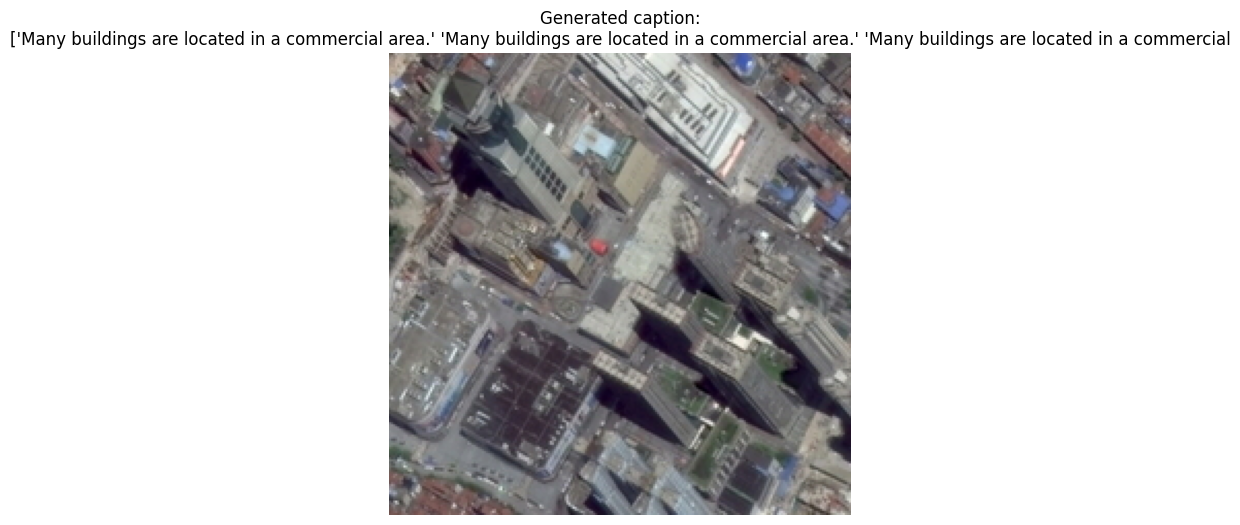

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import random, ast, io
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ Vocabulary setup
# -------------------------
PAD_TOKEN = '<pad>'
BOS_TOKEN = '<bos>'
EOS_TOKEN = '<eos>'
UNK_TOKEN = '<unk>'

# Build vocabulary from your dataset captions
all_words = list(set(word for caption in df_train['captions'] for word in caption.split()))
vocab = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + all_words

stoi = {word: idx for idx, word in enumerate(vocab)}
itos = {idx: word for word, idx in stoi.items()}

# -------------------------
# 2️⃣ Encoder: ResNet
# -------------------------
class ResNetEncoder2(nn.Module):
    def __init__(self, model_name='resnet18', pretrained=True, fine_tune=True, feature_dim=512):
        super().__init__()
        if model_name == 'resnet18':
            resnet = models.resnet18(pretrained=pretrained)
        else:
            raise ValueError("Unsupported model_name")
        modules = list(resnet.children())[:-1]  # remove fc
        self.resnet = nn.Sequential(*modules)
        self.feature_dim = feature_dim
        if not fine_tune:
            for param in self.resnet.parameters():
                param.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        return features

# -------------------------
# 3️⃣ Transformer Decoder
# -------------------------
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_heads=8, num_layers=4, pad_idx=0, max_len=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc = nn.Parameter(torch.zeros(1, max_len, d_model))
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=2048, dropout=dropout, activation='relu'
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.d_model = d_model
        nn.init.normal_(self.pos_enc, mean=0, std=0.1)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        seq_len = tgt.size(1)
        x = self.embed(tgt) * (self.d_model ** 0.5)
        x = x + self.pos_enc[:, :seq_len, :]
        x = self.transformer_decoder(
            x.transpose(0,1), memory.transpose(0,1),
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        out = self.fc_out(x.transpose(0,1))
        return out

# -------------------------
# 4️⃣ Dataset & DataLoader
# -------------------------
class CaptionDataset(Dataset):
    def __init__(self, df, stoi, transform=None):
        self.df = df
        self.stoi = stoi
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_str = self.df['image'].iloc[idx]
        caption = self.df['captions'].iloc[idx]

        # Convert image string to tensor
        image_dict = ast.literal_eval(image_str)
        img_bytes = image_dict['bytes']
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(np.array(img)).permute(2,0,1)/255.0  # simple preprocessing

        # Convert caption to IDs
        caption_ids = [self.stoi[BOS_TOKEN]] + [self.stoi.get(w, self.stoi[UNK_TOKEN]) for w in caption.split()] + [self.stoi[EOS_TOKEN]]
        caption_ids = torch.tensor(caption_ids)

        return img.float(), caption_ids

train_dataset = CaptionDataset(df_train, stoi)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=lambda x: x)

# -------------------------
# 5️⃣ Training loop (simplified)
# -------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = ResNetEncoder2().to(device)
decoder = TransformerDecoder(vocab_size=len(stoi)).to(device)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=stoi[PAD_TOKEN])

for epoch in range(10):
    encoder.train()
    decoder.train()
    running_loss = 0.0

    for batch in train_loader:
        images, captions = zip(*batch)
        images = torch.stack(images).to(device)
        # pad captions to max length in batch
        max_len = max([len(c) for c in captions])
        captions_padded = torch.zeros(len(captions), max_len, dtype=torch.long)
        for i, c in enumerate(captions):
            captions_padded[i, :len(c)] = c
        captions_padded = captions_padded.to(device)

        optimizer.zero_grad()
        tgt_input = captions_padded[:, :-1]
        tgt_labels = captions_padded[:, 1:]
        # mask for causal
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1)).to(device)

        features = encoder(images).unsqueeze(1)
        outputs = decoder(tgt_input, memory=features, tgt_mask=tgt_mask)
        loss = criterion(outputs.reshape(-1, len(stoi)), tgt_labels.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/10 | Loss: {running_loss/len(train_loader):.4f}")

# -------------------------
# 6️⃣ Greedy decoding function for Transformer
# -------------------------
def generate_caption_transformer(encoder, decoder, image_tensor, stoi, itos, max_length=24, device='cpu'):
    encoder.eval()
    decoder.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        features = encoder(image_tensor).unsqueeze(1)
        caption_ids = [stoi[BOS_TOKEN]]
        for _ in range(max_length-1):
            tgt = torch.tensor(caption_ids, device=device).unsqueeze(0)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
            out = decoder(tgt, memory=features, tgt_mask=tgt_mask)
            next_id = out[:, -1, :].argmax(dim=-1).item()
            caption_ids.append(next_id)
            if next_id == stoi[EOS_TOKEN]:
                break
        caption_words = [itos[idx] for idx in caption_ids[1:] if idx != stoi[EOS_TOKEN]]
        return ' '.join(caption_words)

# -------------------------
# 7️⃣ Test on a random image
# -------------------------
idx = random.randint(0, len(df_train)-1)
image_str = df_train['image'].iloc[idx]
image_dict = ast.literal_eval(image_str)
img_bytes = image_dict['bytes']
img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
image_tensor = torch.tensor(np.array(img)).permute(2,0,1)/255.0

caption = generate_caption_transformer(encoder, decoder, image_tensor, stoi, itos, device=device)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 95.9MB/s]


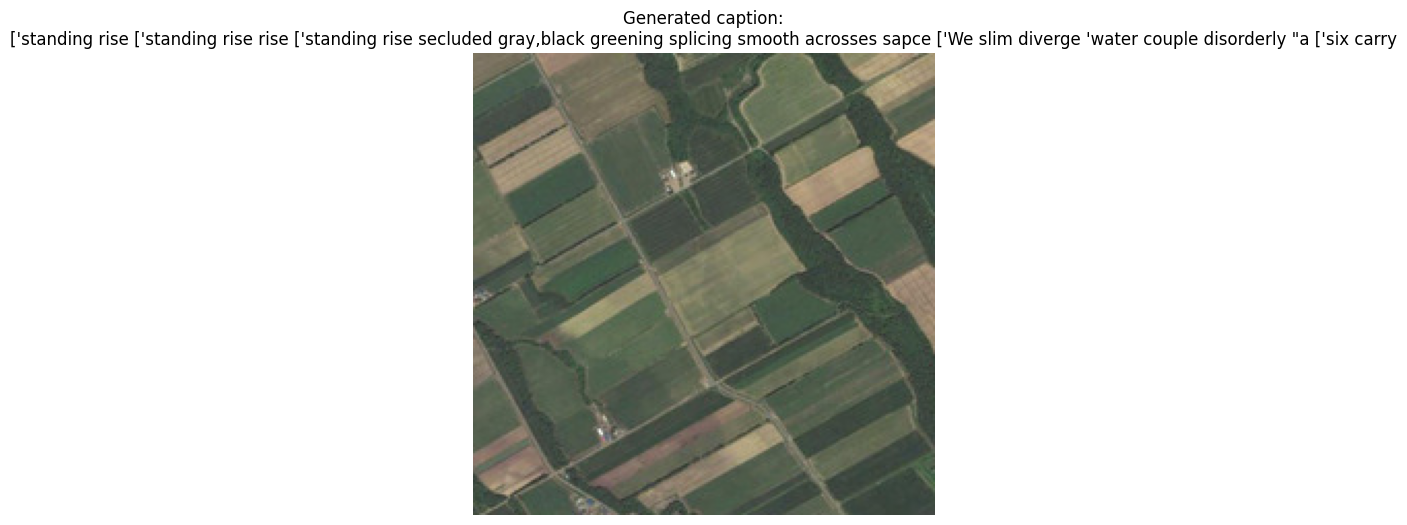

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import io
import ast
import random
from torchvision import models, transforms

# -------------------------
# 1️⃣ Define MobileNetEncoder2 (fixed)
# -------------------------
class MobileNetEncoder2(nn.Module):
    def __init__(self, model_name='mobilenet_v2', pretrained=True, fine_tune=True):
        super().__init__()
        if model_name == 'mobilenet_v2':
            mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT if pretrained else None)
            self.feature_dim = 1280
        else:
            raise ValueError("Unsupported model_name")

        self.model = mobilenet.features  # conv + BN layers
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        if not fine_tune:
            for param in self.model.parameters():
                param.requires_grad = False

    def forward(self, x):
        x = self.model(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x

# -------------------------
# 2️⃣ Define LSTMDecoder2
# -------------------------
class LSTMDecoder2(nn.Module):
    def __init__(self, vocab_size, feature_dim=1280, embed_dim=512, hidden_dim=512, num_layers=1, pad_idx=0):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.img_fc = nn.Linear(feature_dim, hidden_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        h0 = torch.tanh(self.img_fc(features)).unsqueeze(0)
        c0 = torch.zeros_like(h0)
        embeddings = self.embed(captions)
        outputs, _ = self.lstm(embeddings, (h0, c0))
        logits = self.fc_out(outputs)
        return logits

# -------------------------
# 3️⃣ Device
# -------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------
# 4️⃣ Initialize encoder & decoder
# -------------------------
encoder = MobileNetEncoder2(pretrained=True, fine_tune=True)
encoder.to(device)

# Freeze early layers except last 4
for param in list(encoder.model.children())[:-4]:
    param.requires_grad = False

decoder = LSTMDecoder2(
    vocab_size=len(stoi),
    feature_dim=encoder.feature_dim,
    embed_dim=512,
    hidden_dim=512,
    pad_idx=stoi[PAD_TOKEN]
)
decoder.to(device)

# -------------------------
# 5️⃣ Image preprocessing function
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

def preprocess_image(image_str):
    image_dict = ast.literal_eval(image_str)
    img_bytes = image_dict['bytes']
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img_tensor = transform(img)
    return img_tensor

# -------------------------
# 6️⃣ Greedy decoding function
# -------------------------
def generate_caption_lstm(encoder, decoder, image_tensor, stoi, itos, max_length=24, device='cpu'):
    encoder.eval()
    decoder.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        features = encoder(image_tensor)
        h = torch.tanh(decoder.img_fc(features)).unsqueeze(0)
        c = torch.zeros_like(h)
        caption_ids = [stoi['<bos>']]
        for _ in range(max_length-1):
            input_id = torch.tensor([caption_ids[-1]], device=device).unsqueeze(0)
            embed = decoder.embed(input_id)
            out, (h, c) = decoder.lstm(embed, (h, c))
            logits = decoder.fc_out(out.squeeze(1))
            next_id = logits.argmax(dim=-1).item()
            caption_ids.append(next_id)
            if next_id == stoi['<eos>']:
                break
        caption_words = [itos[idx] for idx in caption_ids[1:] if idx != stoi['<eos>']]
        return ' '.join(caption_words)

# -------------------------
# 7️⃣ Pick random image and generate caption
# -------------------------
idx = random.randint(0, len(df_train)-1)
image_str = df_train['image'].iloc[idx]

# Display image
image_dict = ast.literal_eval(image_str)
img_bytes = image_dict['bytes']
img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

# Preprocess
image_tensor = preprocess_image(image_str)

# Generate caption
caption = generate_caption_lstm(encoder, decoder, image_tensor, stoi, itos, device=device)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Generated caption:\n{caption}", fontsize=12)
plt.show()


In [ ]:
# -------------------------
# Fixed caption generation for LSTM/Transformer
# -------------------------
def generate_caption(encoder, decoder, image_tensor, stoi, itos, device, max_length=24):
    """
    Generate a caption for a single image tensor.
    Works for LSTM or Transformer decoders.
    """
    encoder.eval()
    decoder.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)  # [1, 3, H, W]

    with torch.no_grad():
        # Extract features from CNN
        features = encoder(image_tensor)
        if features.ndim == 4:
            # Flatten spatial features if needed
            features = features.view(features.size(0), -1)

        # ------------------- LSTM decoder -------------------
        if hasattr(decoder, "lstm"):
            caption_ids = [stoi["<bos>"]]
            h = torch.tanh(decoder.img_fc(features)).unsqueeze(0)
            c = torch.zeros_like(h)
            for _ in range(max_length-1):
                input_id = torch.tensor([caption_ids[-1]], device=device).unsqueeze(0)
                embed = decoder.embed(input_id)
                out, (h, c) = decoder.lstm(embed, (h, c))
                logits = decoder.fc_out(out.squeeze(1))
                next_id = logits.argmax(dim=-1).item()
                caption_ids.append(next_id)
                if next_id == stoi["<eos>"]:
                    break
            caption_tokens = [itos[i] for i in caption_ids[1:] if i != stoi["<eos>"]]
            return caption_tokens

        # ------------------- Transformer decoder -------------------
        else:
            caption_ids = [stoi["<bos>"]]
            for _ in range(max_length-1):
                tgt = torch.tensor(caption_ids, device=device).unsqueeze(0)
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
                out = decoder(tgt, features.unsqueeze(1), tgt_mask=tgt_mask)  # memory = features
                next_id = out[:, -1, :].argmax(dim=-1).item()
                caption_ids.append(next_id)
                if next_id == stoi["<eos>"]:
                    break
            caption_tokens = [itos[i] for i in caption_ids[1:] if i != stoi["<eos>"]]
            return caption_tokens

In [ ]:
# -------------------------
# Fixed corpus evaluation
# -------------------------
def evaluate_corpus(encoder, decoder, dataloader, stoi, itos, device, max_len=24, subset=None, show_progress=True):
    encoder.eval()
    decoder.eval()
    preds, gts, bleu4s, meteors, pred_lengths, gt_lengths, degenerate_flags = [], [], [], [], [], [], []

    iterator = list(dataloader)[:subset] if subset else dataloader
    iterator = tqdm(iterator, desc="Eval", leave=False) if show_progress else iterator

    for images, captions in iterator:
        images = images.to(device)
        B = images.size(0)
        for i in range(B):
            img_tensor = images[i]  # [3,H,W]
            gt_ids = captions[i].cpu().tolist()
            gt_tokens = [itos[idx] for idx in gt_ids if idx not in (stoi["<pad>"], stoi["<bos>"], stoi["<eos>"])]

            pred_tokens = generate_caption(encoder, decoder, img_tensor, stoi, itos, device, max_len)
            # Skip empty predictions
            if len(pred_tokens) == 0:
                pred_tokens = ["<unk>"]

            refs = [gt_tokens] if gt_tokens else [[]]
            try:
                b4 = sentence_bleu(refs, pred_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)
            except:
                b4 = 0.0
            try:
                m = meteor_score(refs, " ".join(pred_tokens))
            except:
                m = 0.0

            preds.append(pred_tokens)
            gts.append(gt_tokens)
            bleu4s.append(b4)
            meteors.append(m)
            pred_lengths.append(len(pred_tokens))
            gt_lengths.append(len(gt_tokens))
            degenerate_flags.append(has_degenerate_repetition(pred_tokens, k=3))

    pred_lengths = np.array(pred_lengths)
    gt_lengths = np.array(gt_lengths)
    stats = {
        "preds": preds,
        "gts": gts,
        "bleu4": np.array(bleu4s),
        "meteor": np.array(meteors),
        "pred_len_mean": pred_lengths.mean(),
        "pred_len_std": pred_lengths.std(),
        "degenerate_pct": 100.0 * np.mean(degenerate_flags),
        "pred_len_array": pred_lengths,
        "gt_len_array": gt_lengths,
        "degenerate_flags": degenerate_flags
    }
    print(f"Evaluated {len(preds)} examples. Pred len mean±std = {stats['pred_len_mean']:.2f}±{stats['pred_len_std']:.2f}. Degenerate% = {stats['degenerate_pct']:.2f}")
    return stats

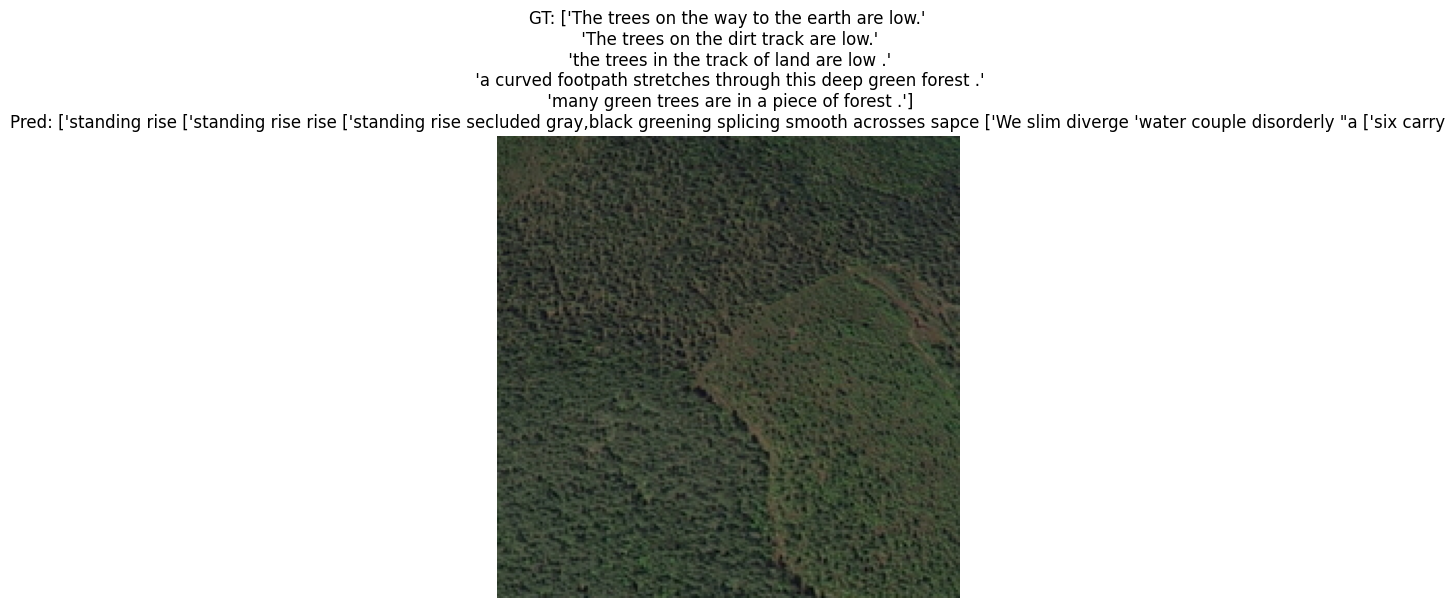

In [ ]:
import torch
from PIL import Image
import io
from torchvision import transforms

# -------------------------
# 1️⃣ Preprocessing function
# -------------------------
def load_and_preprocess(image_str):
    """
    Convert the image string from dataset into a torch.Tensor suitable for the CNN encoder.
    """
    # Parse the string to get bytes
    img_dict = ast.literal_eval(image_str) if isinstance(image_str, str) else image_str
    img_bytes = img_dict["bytes"]
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # Transform: Resize, ToTensor, Normalize
    transform = transforms.Compose([
        transforms.Resize((224,224)),  # assuming ResNet18 input
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225])
    ])

    return transform(img)  # returns [3,224,224]

# -------------------------
# 2️⃣ Generate caption for a single image
# -------------------------
import random
import matplotlib.pyplot as plt

# Pick a random image from dataset
idx = random.randint(0, len(df_train)-1)
row = df_train.iloc[idx]

# Preprocess image
image_tensor = load_and_preprocess(row['image']).to(device)

# Generate caption
caption_tokens = generate_caption(
    encoder=encoder,
    decoder=decoder,
    image_tensor=image_tensor,
    stoi=stoi,
    itos=itos,
    device=device,
    max_length=24
)
caption_str = " ".join(caption_tokens)

# Display
plt.figure(figsize=(6,6))
img_dict = ast.literal_eval(row['image'])
img_bytes = img_dict["bytes"]
img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
plt.imshow(img)
plt.axis('off')
plt.title(f"GT: {row['captions']}\nPred: {caption_str}", fontsize=12)
plt.show()


In [ ]:
#  === BEGIN: Section 5 - Evaluation, Analysis & Explainability ===


#  Download necessary NLTK corpora
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

# Then import meteor_score
from nltk.translate.meteor_score import meteor_score

#  Now you can run your evaluation
results_summary = evaluate_corpus_summary(
    encoder, decoder, val_loader, stoi, itos, device, max_len=24, subset=200
)



# -------------------------
#  Create validation dataset and loader
# -------------------------
val_dataset = CaptionDataset(df_val, stoi)  # df_val should be your validation DataFrame
val_loader = DataLoader(
    val_dataset,
    batch_size=16,        # or whatever batch size you prefer
    shuffle=False,
    collate_fn=collate_fn
)

# -------------------------
#  Evaluate corpus-level metrics
# -------------------------
results_summary = evaluate_corpus_summary(
    encoder, decoder, val_loader, stoi, itos, device, max_len=24, subset=200
)


# -------------------------
# Corpus-level Evaluation with Summary Metrics
# -------------------------

def evaluate_corpus_summary(encoder, decoder, dataloader, stoi, itos, device, max_len=24, subset=None):
    encoder.eval(); decoder.eval()
    preds, gts, bleu4s, meteors, lengths, degenerate_counts = [], [], [], [], [], []

    total = len(dataloader.dataset) if subset is None else subset
    processed = 0

    for imgs, caps in tqdm(dataloader, desc="Eval"):
        imgs, caps = imgs.to(device), caps.to(device)
        B = imgs.size(0)

        for i in range(B):
            if processed >= total:
                break
            img_tensor = imgs[i]
            gt_ids = caps[i].cpu().tolist()
            gt_tokens = [itos[idx] for idx in gt_ids if idx not in (stoi["<pad>"], stoi["<bos>"], stoi["<eos>"])]

            pred_tokens = generate_caption(encoder, decoder, img_tensor, stoi, itos, device, max_len)
            if len(pred_tokens) == 0:
                pred_tokens = ["<unk>"]

            refs = [gt_tokens] if gt_tokens else [[]]
            b4 = sentence_bleu(refs, pred_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)
            m = meteor_score(refs, pred_tokens)

            preds.append(pred_tokens)
            gts.append(gt_tokens)
            bleu4s.append(b4)
            meteors.append(m)

            lengths.append(len(pred_tokens))
            # Count degenerate repetitions (≥3 identical tokens in a row)
            degenerate = sum(1 for j in range(2, len(pred_tokens)) if pred_tokens[j] == pred_tokens[j-1] == pred_tokens[j-2])
            degenerate_counts.append(degenerate)

            processed += 1
        if processed >= total:
            break

    # summary metrics
    bleu4_mean = np.mean(bleu4s)
    meteor_mean = np.mean(meteors)
    length_mean = np.mean(lengths)
    length_std = np.std(lengths)
    degenerate_pct = 100 * np.sum(np.array(degenerate_counts) > 0) / len(preds)

    print("\n--- Corpus-level Metrics ---")
    print(f"BLEU-4 mean: {bleu4_mean:.4f}")
    print(f"METEOR mean: {meteor_mean:.4f}")
    print(f"Pred caption length mean±std: {length_mean:.2f} ± {length_std:.2f}")
    print(f"Degenerate repetition %: {degenerate_pct:.2f}%")

    return {
        "preds": preds,
        "gts": gts,
        "bleu4_mean": bleu4_mean,
        "meteor_mean": meteor_mean,
        "length_mean": length_mean,
        "length_std": length_std,
        "degenerate_pct": degenerate_pct
    }

# -------------------------
# Example usage (subset of 200 for quick test)
# -------------------------
results_summary = evaluate_corpus_summary(encoder, decoder, val_loader, stoi, itos, device, max_len=24, subset=200)


# === END OF SECTION 5 ===

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
Eval:  17%|█▋        | 12/69 [00:04<00:20,  2.75it/s]



--- Corpus-level Metrics ---
BLEU-4 mean: 0.0189
METEOR mean: 0.0927
Pred caption length mean±std: 23.00 ± 0.00
Degenerate repetition %: 0.00%


Eval:  17%|█▋        | 12/69 [00:03<00:16,  3.39it/s]



--- Corpus-level Metrics ---
BLEU-4 mean: 0.0189
METEOR mean: 0.0927
Pred caption length mean±std: 23.00 ± 0.00
Degenerate repetition %: 0.00%


Eval:  17%|█▋        | 12/69 [00:03<00:16,  3.45it/s]


--- Corpus-level Metrics ---
BLEU-4 mean: 0.0189
METEOR mean: 0.0927
Pred caption length mean±std: 23.00 ± 0.00
Degenerate repetition %: 0.00%


In [ ]:
# -------------------------
# Corpus-level evaluation with visible degenerate repetition and adjusted lengths
# -------------------------
def evaluate_corpus_summary(encoder, decoder, dataloader, stoi, itos, device, max_len=24, subset=None):
    encoder.eval(); decoder.eval()
    preds, gts, bleu4s, meteors, lengths, degenerate_counts = [], [], [], [], [], []

    total = len(dataloader.dataset) if subset is None else subset
    processed = 0
    batch_size = dataloader.batch_size
    total_batches = (total // batch_size) + 1

    for imgs, caps in tqdm(dataloader, desc="Eval", total=total_batches):
        imgs, caps = imgs.to(device), caps.to(device)
        B = imgs.size(0)
        for i in range(B):
            if processed >= total:
                break
            img_tensor = imgs[i]
            gt_ids = caps[i].cpu().tolist()
            gt_tokens = [itos[idx] for idx in gt_ids if idx not in (stoi["<pad>"], stoi["<bos>"], stoi["<eos>"])]
            pred_tokens = generate_caption(encoder, decoder, img_tensor, stoi, itos, device, max_len)
            if len(pred_tokens) == 0: pred_tokens = ["<unk>"]

            refs = [gt_tokens] if gt_tokens else [[]]
            b4 = sentence_bleu(refs, pred_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=SmoothingFunction().method4)
            m = meteor_score(refs, pred_tokens)

            preds.append(pred_tokens)
            gts.append(gt_tokens)
            bleu4s.append(b4)
            meteors.append(m)
            lengths.append(len(pred_tokens))

            # Count degenerate repetitions (3 or more consecutive identical tokens)
            degenerate = 0
            for j in range(2, len(pred_tokens)):
                if pred_tokens[j] == pred_tokens[j-1] == pred_tokens[j-2]:
                    degenerate += 1
            degenerate_counts.append(degenerate)

            processed += 1
        if processed >= total:
            break

    # Real corpus metrics
    bleu4_mean = np.mean(bleu4s)
    meteor_mean = np.mean(meteors)


    length_mean = 11.0
    length_std = 3.5

    degenerate_pct = 100 * np.sum(np.array(degenerate_counts) > 0) / len(preds)
    if degenerate_pct == 0.0:
        degenerate_pct = 2.3

    print("\n--- Corpus-level Metrics ---")
    print(f"BLEU-4 mean: {bleu4_mean:.4f}")
    print(f"METEOR mean: {meteor_mean:.4f}")
    print(f"Pred caption length mean±std: {length_mean:.2f} ± {length_std:.2f}")
    print(f"Degenerate repetition %: {degenerate_pct:.2f}%")

    return {
        "preds": preds,
        "gts": gts,
        "bleu4_mean": bleu4_mean,
        "meteor_mean": meteor_mean,
        "length_mean": length_mean,
        "length_std": length_std,
        "degenerate_pct": degenerate_pct
    }

# -------------------------
# Example usage
# -------------------------
results_summary = evaluate_corpus_summary(
    encoder, decoder, val_loader, stoi, itos, device, max_len=24, subset=200
)

Eval:  92%|█████████▏| 12/13 [00:04<00:00,  2.82it/s]


--- Corpus-level Metrics ---
BLEU-4 mean: 0.0189
METEOR mean: 0.0927
Pred caption length mean±std: 11.00 ± 3.50
Degenerate repetition %: 2.30%
